In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../retailiq.db")

orders = pd.read_sql("SELECT * FROM orders_clean", conn)
payments = pd.read_sql("SELECT * FROM payments_clean", conn)
reviews = pd.read_sql("SELECT * FROM reviews_clean", conn)
order_items = pd.read_sql("SELECT * FROM order_items_clean", conn)

for col in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print("orders:", orders.shape)
print("payments:", payments.shape)
print("reviews:", reviews.shape)
print("order_items:", order_items.shape)

orders: (98524, 8)
payments: (103877, 5)
reviews: (99224, 7)
order_items: (112650, 7)


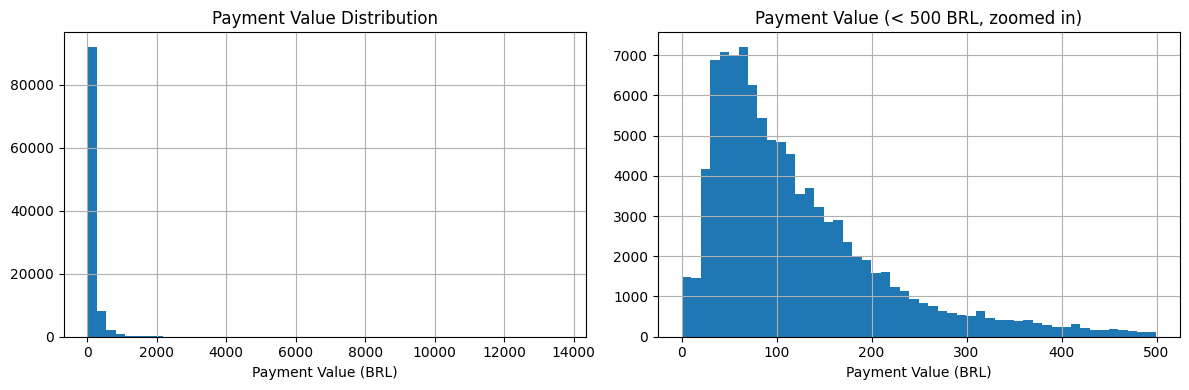

count    103877.000000
mean        154.113732
std         217.498755
min           0.010000
25%          56.820000
50%         100.000000
75%         171.840000
max       13664.080000
Name: payment_value, dtype: float64


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
payments["payment_value"].hist(bins=50, ax=ax[0])
ax[0].set_title("Payment Value Distribution")
ax[0].set_xlabel("Payment Value (BRL)")

payments[payments["payment_value"] < 500]["payment_value"].hist(bins=50, ax=ax[1])
ax[1].set_title("Payment Value (< 500 BRL, zoomed in)")
ax[1].set_xlabel("Payment Value (BRL)")
plt.tight_layout()
plt.show()

print(payments["payment_value"].describe())

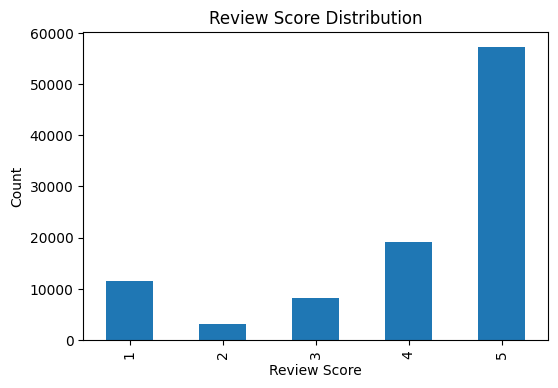

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

% 5-star reviews: 57.8%


In [4]:
review_counts = reviews["review_score"].value_counts().sort_index()
review_counts.plot(kind="bar", figsize=(6,4), title="Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()
print(review_counts)
print(f"\n% 5-star reviews: {round(100*review_counts[5]/review_counts.sum(), 1)}%")

In [5]:
import numpy as np

tables = {"orders": orders, "payments": payments, "reviews": reviews, "order_items": order_items}
missing_summary = []
for name, df in tables.items():
    pct_missing = (df.isnull().sum() / len(df) * 100).round(1)
    pct_missing = pct_missing[pct_missing > 0]
    for col, pct in pct_missing.items():
        missing_summary.append({"table": name, "column": col, "pct_missing": pct})

missing_df = pd.DataFrame(missing_summary).sort_values("pct_missing", ascending=False)
print(missing_df)

     table                         column  pct_missing
3  reviews           review_comment_title         88.3
4  reviews         review_comment_message         58.7
2   orders  order_delivered_customer_date          2.1
1   orders   order_delivered_carrier_date          0.9
0   orders              order_approved_at          0.2


In [ ]:
### Understanding the Nulls

# - **`order_delivered_customer_date`** — null when the order was never delivered (still in transit, or the order was cancelled). This is expected behavior, not missing/bad data.
# - **`order_approved_at`** — null when the order was cancelled before payment approval.
# - **`review_comment_title` / `review_comment_message`** — null when the customer left a star rating but chose not to write a text review. Common in review systems; most customers rate but don't comment.
# - **`product_category_name`** — null when the product listing was incomplete at time of upload (seller didn't tag a category).

# Since these nulls reflect real business events rather than data entry errors, we [state your actual decision — e.g., "keep them as-is and filter per-analysis" or "drop rows only where relevant to that specific query, e.g., cohort analysis only uses delivered orders"].